<a href="https://colab.research.google.com/github/vgayathri13/VRSU/blob/main/VRSU_3DReconstruction11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== 3D Reconstruction Results ===
Point   Real Z      Reconstructed Z
------------------------------------
  P1    5.00        5.00
  P2    4.00        4.00
  P3    6.00        6.00
  P4    3.50        3.50
  P5    4.50        4.50


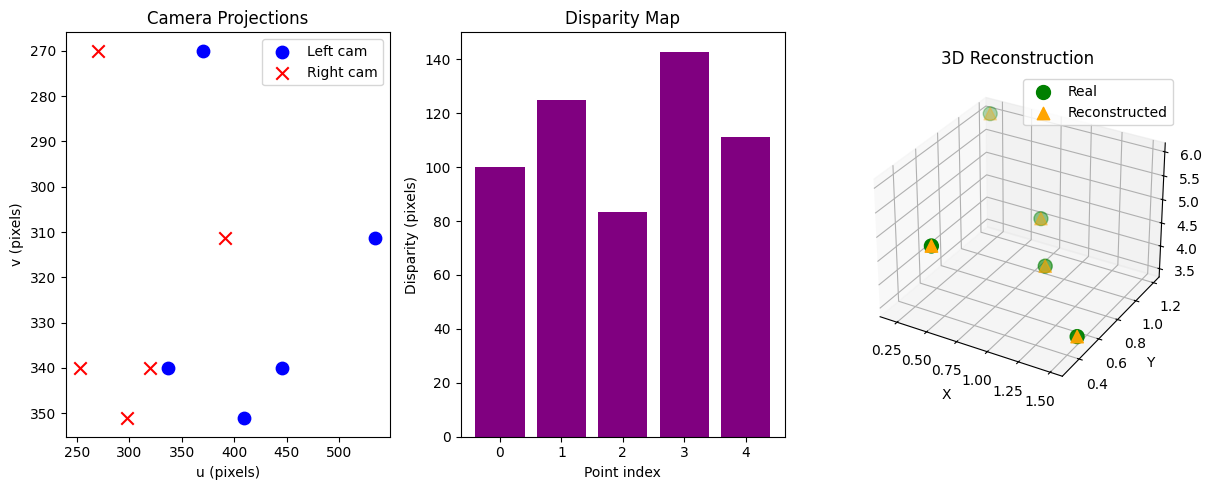


Plot saved as 3d_reconstruction.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Simulate two camera views (stereo vision)
# Camera 1: at origin, Camera 2: shifted right by baseline
baseline = 1.0        # distance between cameras (meters)
focal_length = 500    # focal length in pixels
image_width = 640
image_height = 480

# 3D points in the real world (x, y, z)
real_points = np.array([
    [0.5, 0.3, 5.0],
    [1.0, 0.8, 4.0],
    [0.2, 1.2, 6.0],
    [1.5, 0.5, 3.5],
    [0.8, 1.0, 4.5],
])

def project_to_image(points, cam_x=0):
    """Project 3D points onto 2D image plane."""
    projected = []
    for p in points:
        x, y, z = p[0] - cam_x, p[1], p[2]
        u = focal_length * x / z + image_width / 2
        v = focal_length * y / z + image_height / 2
        projected.append((u, v))
    return np.array(projected)

# Project points from both cameras
left_proj  = project_to_image(real_points, cam_x=0)
right_proj = project_to_image(real_points, cam_x=baseline)

# Compute disparity (difference in x between left & right)
disparity = left_proj[:, 0] - right_proj[:, 0]

# Reconstruct depth from disparity
# depth = (focal_length * baseline) / disparity
depth_reconstructed = (focal_length * baseline) / disparity

print("=== 3D Reconstruction Results ===")
print(f"{'Point':<8}{'Real Z':<12}{'Reconstructed Z'}")
print("-" * 36)
for i, (real, recon) in enumerate(
        zip(real_points[:, 2], depth_reconstructed)):
    print(f"  P{i+1}    {real:<12.2f}{recon:.2f}")

# Reconstruct full 3D coordinates
reconstructed_x = (left_proj[:,0] - image_width/2)  \
                   * depth_reconstructed / focal_length
reconstructed_y = (left_proj[:,1] - image_height/2) \
                   * depth_reconstructed / focal_length

# --- Plot ---
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(131)
ax1.scatter(left_proj[:,0], left_proj[:,1],
            c='blue', s=80, label='Left cam')
ax1.scatter(right_proj[:,0], right_proj[:,1],
            c='red', s=80, label='Right cam', marker='x')
ax1.set_title("Camera Projections")
ax1.set_xlabel("u (pixels)")
ax1.set_ylabel("v (pixels)")
ax1.legend(); ax1.invert_yaxis()

ax2 = fig.add_subplot(132)
ax2.bar(range(len(disparity)), disparity, color='purple')
ax2.set_title("Disparity Map")
ax2.set_xlabel("Point index")
ax2.set_ylabel("Disparity (pixels)")

ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(real_points[:,0], real_points[:,1],
            real_points[:,2], c='green', s=100,
            label='Real', marker='o')
ax3.scatter(reconstructed_x, reconstructed_y,
            depth_reconstructed, c='orange', s=80,
            label='Reconstructed', marker='^')
ax3.set_title("3D Reconstruction")
ax3.set_xlabel("X"); ax3.set_ylabel("Y"); ax3.set_zlabel("Z")
ax3.legend()

plt.tight_layout()
plt.savefig("3d_reconstruction.png", dpi=100)
plt.show()
print("\nPlot saved as 3d_reconstruction.png")